# Activity: Evaluate simple linear regression

## Introduction

In this activity, you will use simple linear regression to explore the relationship between two continuous variables. To accomplish this, you will perform a complete simple linear regression analysis, which includes creating and fitting a model, checking model assumptions, analyzing model performance, interpreting model coefficients, and communicating results to stakeholders.

For this activity, you are part of an analytics team that provides insights about marketing and sales. You have been assigned to a project that focuses on the use of influencer marketing, and you would like to explore the relationship between marketing promotional budgets and sales. The dataset provided includes information about marketing campaigns across TV, radio, and social media, as well as how much revenue in sales was generated from these campaigns. Based on this information, leaders in your company will make decisions about where to focus future marketing efforts, so it is critical to have a clear understanding of the relationship between the different types of marketing and the revenue they generate.

This activity will develop your knowledge of linear regression and your skills evaluating regression results which will help prepare you for modeling to provide business recommendations in the future.

## Step 1: Imports

### Import packages

Import relevant Python libraries and packages. In this activity, you will need to use `pandas`, `pyplot` from `matplotlib`, and `seaborn`.

In [3]:
# Import pandas, pyplot from matplotlib, and seaborn.

### YOUR CODE HERE ### 
# Import pandas, pyplot from matplotlib, and seaborn.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import the statsmodel module and the ols function

Import the `statsmodels.api` Python module using its common abbreviation, `sm`, along with the `ols()` function from `statsmodels.formula.api`. To complete this, you will need to write the imports as well.

In [4]:
# Import the statsmodel module.

# Import the ols function from statsmodels.

### YOUR CODE HERE ###
# Import the statsmodel module.
import statsmodels.api as sm

# Import the ols function from statsmodels.
from statsmodels.formula.api import ols

### Load the dataset

`Pandas` was used to load the provided dataset `marketing_and_sales_data_evaluate_lr.csv` as `data`, now display the first five rows. This is a fictional dataset that was created for educational purposes. The variables in the dataset have been kept as is to suit the objectives of this activity. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [5]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

### YOUR CODE HERE ###
data = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')

# Display the first five rows.

### YOUR CODE HERE ### 
data.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


## Step 2: Data exploration

### Familiarize yourself with the data's features

Start with an exploratory data analysis to familiarize yourself with the data and prepare it for modeling.

The features in the data are:
* TV promotion budget (in millions of dollars)
* Social media promotion budget (in millions of dollars)
* Radio promotion budget (in millions of dollars)
* Sales (in millions of dollars)

Each row corresponds to an independent marketing promotion where the business invests in `TV`, `Social_Media`, and `Radio` promotions to increase `Sales`.

The business would like to determine which feature most strongly predicts `Sales` so they have a better understanding of what promotions they should invest in in the future. To accomplish this, you'll construct a simple linear regression model that predicts sales using a single independent variable. 

**Question:** What are some reasons for conducting an EDA before constructing a simple linear regression model?

Respuesta / Response: Español: Realizar un Análisis Exploratorio de Datos (EDA) antes de construir un modelo de regresión lineal simple es fundamental por varias razones clave:

Verificar el supuesto de linealidad: Permite confirmar mediante gráficos de dispersión si realmente existe una relación en forma de línea recta entre la variable independiente (X) y la variable dependiente (Y).

Detectar valores atípicos (outliers): Ayuda a identificar puntos de datos extremos que podrían distorsionar la pendiente de la línea de regresión y afectar métricas sensibles como el MSE.

Evaluar la calidad de los datos: Permite revisar si existen datos faltantes (valores nulos) o inconsistencias que deban limpiarse antes de entrenar el modelo.

Seleccionar la mejor variable: En este caso específico, ayuda a comparar visualmente TV, Radio y Social Media para elegir cuál de ellas tiene la correlación más fuerte y limpia con las ventas.

English: Conducting an Exploratory Data Analysis (EDA) before constructing a simple linear regression model is essential for several key reasons:

Verify the linearity assumption: It allows us to confirm through scatter plots whether a straight-line relationship actually exists between the independent variable (X) and the dependent variable (Y).

Detect outliers: It helps identify extreme data points that could distort the slope of the regression line and heavily impact sensitive metrics like MSE.

Assess data quality: It checks for missing data (null values) or inconsistencies that need to be cleaned before training the model.

Select the best feature: In this specific case, it helps visually compare TV, Radio, and Social Media to choose which one has the strongest and cleanest correlation with sales.

### Explore the data size

Calculate the number of rows and columns in the data.

In [6]:
# Display the shape of the data as a tuple (rows, columns).

### YOUR CODE HERE ### 
# Display the shape of the data as a tuple (rows, columns).

data.shape

(4572, 4)

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

There is an attribute of a pandas DataFrame that returns the dimension of the DataFrame.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

The `shape` attribute of a DataFrame returns a tuple with the array dimensions.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use `data.shape`, which returns a tuple with the number of rows and columns.

</details>

### Explore the independent variables

There are three continuous independent variables: `TV`, `Radio`, and `Social_Media`. To understand how heavily the business invests in each promotion type, use `describe()` to generate descriptive statistics for these three variables.

In [7]:
# Generate descriptive statistics about TV, Radio, and Social_Media.

### YOUR CODE HERE ###
# Generate descriptive statistics about TV, Radio, and Social_Media.

data[['TV', 'Radio', 'Social_Media']].describe()

,TV,Radio,Social_Media
count,4562.000000,4568.000000,4566.000000
mean,54.066857,18.160356,3.323956
std,26.125054,9.676958,2.212670
min,10.000000,0.000684,0.000031
25%,32.000000,10.525957,1.527849
50%,53.000000,17.859513,3.055565
75%,77.000000,25.649730,4.807558
max,100.000000,48.871161,13.981662


Resumen del Análisis Exploratorio / Exploratory Analysis Summary
Español
Dimensiones del Conjunto de Datos: El archivo contiene originalmente 4,572 filas y 4 columnas (TV, Radio, Social_Media, Sales), lo que representa un volumen de datos robusto y confiable para el modelado lineal.

Estrategia Actual de Inversión: * La Televisión (TV) es el canal dominante del negocio, con un presupuesto promedio de 54.06 millones de dólares por campaña.

La Radio ocupa el segundo lugar con un promedio de 18.16 millones de dólares.

Las Redes Sociales (Social_Media) reciben la menor inversión, con apenas 3.32 millones de dólares en promedio.

Hallazgo Crítico (Calidad de Datos): Al comparar las filas totales con la métrica count de la estadística descriptiva, se detectó la presencia de valores nulos (NaN) distribuidos en las tres variables independientes (10 en TV, 4 en Radio y 6 en Redes Sociales). Estas filas vacías deben ser limpiadas o eliminadas antes de ajustar el modelo OLS.

English
Dataset Dimensions: The file originally contains 4,572 rows and 4 columns (TV, Radio, Social_Media, Sales), which represents a robust and reliable data volume for linear modeling.

Current Investment Strategy: * Television (TV) is the business's dominant channel, with an average budget of $54.06 million per campaign.

Radio ranks second, with an average investment of $18.16 million.

Social Media (Social_Media) receives the lowest budget, averaging just $3.32 million.

Critical Finding (Data Quality): By comparing the total rows against the count metric in the descriptive statistics, the presence of missing values (NaN) was detected across all three independent variables (10 in TV, 4 in Radio, and 6 in Social Media). These empty rows must be cleaned or dropped before fitting the OLS model.

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Subset `data` to only include the columns of interest.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Select the columns of interest using `data[['TV','Radio','Social_Media']]`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Apply `describe()` to the data subset.

</details>

### Explore the dependent variable

Before fitting the model, ensure the `Sales` for each promotion (i.e., row) is present. If the `Sales` in a row is missing, that row isn't of much value to the simple linear regression model.

Display the percentage of missing values in the `Sales` column in the DataFrame `data`.

In [8]:
# Calculate the average missing rate in the sales column.

### YOUR CODE HERE ###
missing_sales = data['Sales'].isna().mean()
# Convert the missing_sales from a decimal to a percentage and round to 2 decimal place.

### YOUR CODE HERE ###
missing_sales_pct = round(missing_sales * 100, 2)
# Display the results (missing_sales must be converted to a string to be concatenated in the print statement).

### YOUR CODE HERE ###
print("Percentage of missing values in the Sales column: " + str(missing_sales_pct) + "%")

Percentage of missing values in the Sales column: 0.13%


**Question:** What do you observe about the percentage of missing values in the `Sales` column?

Español:
El porcentaje de valores faltantes en la columna Sales es extremadamente bajo (0.13%). Esto equivale a solo unas pocas filas de las 4,572 originales. Debido a que la cantidad de datos perdidos es insignificante, eliminar estas filas con valores nulos no afectará el poder estadístico ni sesgará los resultados de nuestro modelo de regresión lineal simple.

English:
The percentage of missing values in the Sales column is extremely low (0.13%). This equates to only a few rows out of the original 4,572. Since the amount of missing data is negligible, dropping these rows will not impact the statistical power or introduce bias into our simple linear regression model.

### Remove the missing data

Remove all rows in the data from which `Sales` is missing.

In [9]:
# Subset the data to include rows where Sales is present.

### YOUR CODE HERE ### 
data = data.dropna(subset=['Sales'])

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about removing missing values from a DataFrame](https://www.coursera.org/learn/go-beyond-the-numbers-translate-data-into-insight/lecture/rUXcJ/work-with-missing-data-in-a-python-notebook).

</details>


<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

The `dropna()` function may be helpful.

</details>


<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Apply `dropna()` to `data` and use the `subset` and `axis` arguments to drop rows where `Sales` is missing. 

</details>


### Visualize the sales distribution

Create a histogram to visualize the distribution of `Sales`.

Text(0, 0.5, 'Count')

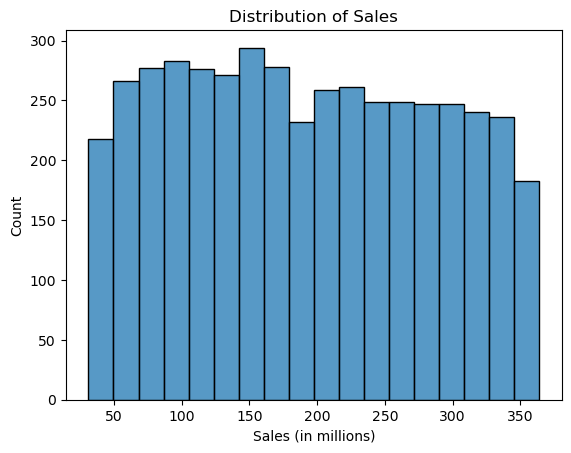

In [10]:
# Create a histogram of the Sales.
sns.histplot(data['Sales'])

# Add a title
plt.title('Distribution of Sales')

# Ensure labels are readable
plt.xlabel('Sales (in millions)')
plt.ylabel('Count')

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Use the function in the `seaborn` library that allows you to create a histogram.

</details>


<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Call the `histplot()` function from the `seaborn` library and pass in the `Sales` column as the argument.

</details>


<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

To get a specific column from a DataFrame, use a pair of single square brackets and place the name of the column, as a string, in the brackets. Be sure that the spelling, including case, matches the data exactly.

</details>


**Question:** What do you observe about the distribution of `Sales` from the preceding histogram?

Español:
A partir del histograma, se observa que la distribución de la variable Sales (Ventas) es aproximadamente uniforme en el rango de los 50 a los 350 millones de dólares. No presenta una forma de campana de Gauss tradicional (distribución normal), sino que las frecuencias se mantienen bastante constantes y estables en la mayor parte de los intervalos. Asimismo, no se aprecian sesgos extremos (skewness) ni la presencia visual de valores atípicos (outliers) evidentes. Esto indica que el conjunto de datos cubre de manera homogénea una amplia gama de resultados de ventas, lo cual es muy útil para evaluar cómo impactan los presupuestos de marketing en todo ese espectro.

English:
Based on the histogram, the distribution of the Sales variable is approximately uniform within the range of 50 to 350 million dollars. It does not exhibit a traditional bell-shaped curve (normal distribution); instead, the frequencies remain fairly constant and stable across most intervals. Additionally, there is no evidence of extreme skewness or visible outliers. This indicates that the dataset evenly covers a wide spectrum of sales outcomes, which is highly useful for evaluating how marketing budgets impact performance across that entire range.

## Step 3: Model building

Create a pairplot to visualize the relationships between pairs of variables in the data. You will use this to visually determine which variable has the strongest linear relationship with `Sales`. This will help you select the X variable for the simple linear regression.

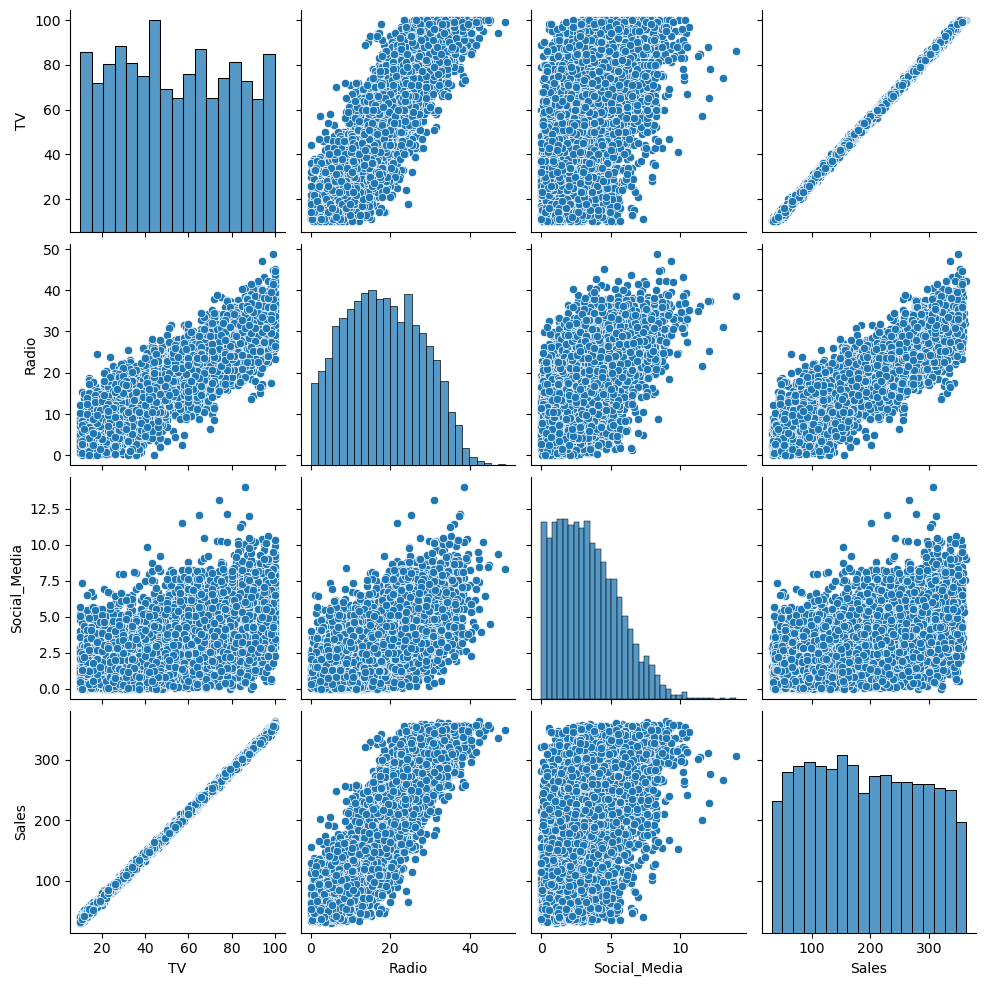

In [11]:
# Create a pairplot of the data.

### YOUR CODE HERE ### 
# Create a pairplot of the data.

sns.pairplot(data)

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the video where creating a pairplot is demonstrated](https://www.coursera.org/learn/regression-analysis-simplify-complex-data-relationships/lecture/dnjWm/explore-linear-regression-with-python).

</details>


<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the function in the `seaborn` library that allows you to create a pairplot that shows the relationships between variables in the data.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use the [`pairplot()`](https://seaborn.pydata.org/generated/seaborn.pairplot.html) function from the `seaborn` library and pass in the entire DataFrame.

</details>


**Question:** Which variable did you select for X? Why?

Español:
Seleccioné la variable TV para ocupar el lugar de X (la variable independiente) en el modelo de regresión lineal simple.

¿Por qué?
Al analizar la última fila del gráfico de pares (pairplot), la relación entre TV y Sales muestra una línea diagonal ascendente sumamente clara, recta y compacta, con una dispersión de puntos mínima en comparación con las otras variables. Esto evidencia una correlación lineal positiva extremadamente fuerte. En contraste, la Radio muestra una dispersión mucho más amplia (mayor variabilidad) y las redes sociales (Social_Media) presentan una nube de puntos difusa con una tendencia lineal muy débil. Por lo tanto, el presupuesto de televisión es el predictor más robusto y confiable para las ventas del negocio.

English:
I selected TV as the X variable (independent variable) for the simple linear regression model.

Why?
When analyzing the bottom row of the pairplot, the relationship between TV and Sales displays a highly distinct, straight, and tight upward diagonal line, with minimal data point dispersion compared to the other variables. This provides clear visual evidence of an extremely strong positive linear correlation. In contrast, Radio shows a much wider scatter (higher variability), and Social_Media presents a diffuse cloud of points with a very weak linear trend. Therefore, the television budget is the most robust and reliable predictor of the business's sales.

### Build and fit the model

Replace the comment with the correct code. Use the variable you chose for `X` for building the model.

In [12]:
# Define the OLS formula.

### YOUR CODE HERE ### 

# Define the OLS formula.
ols_formula = 'Sales ~ TV'

# Create an OLS model.

### YOUR CODE HERE ### 
OLS_model = ols(formula=ols_formula, data=data)

# Fit the model.

### YOUR CODE HERE ### 
model = OLS_model.fit()

# Save the results summary.

### YOUR CODE HERE ### 
model_summary = model.summary()

# Display the model results.

### YOUR CODE HERE ### 
model_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        22:28:00   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1263      0.101     -1.257      0.209      -0.323       0.071
TV             3.5614      0.002   2127.776      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.051   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.975   Jarque-Bera (JB):                0.030
Skew:                           0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Resumen de Resultados del Modelo OLS / OLS Model Results Summary
Español
Poder Predictivo Excepcional (R 2 =0.999): El coeficiente de determinación indica que el 99.9% de la variación en las Ventas (Sales) está explicada de manera directa por el presupuesto invertido en Televisión (TV). El modelo tiene un ajuste casi perfecto con los datos históricos.

Ecuación de Regresión Estimada:
Sales = -0.1263 + 3.5614 X TV

Impacto Marginal de la Inversión (β 1 =3.5614): El coeficiente de la pendiente demuestra que por cada incremento de 1 millón de dólares en el presupuesto publicitario de TV, las ventas del negocio aumentan, en promedio, 3.5614 millones de dólares.

Significancia Estadística (p-value=0.000): El valor p para la variable TV es inferior a 0.05, lo que confirma que la relación lineal positiva encontrada es altamente significativa y no es obra del azar.

Validación de Supuestos (Durbin-Watson = 2.002): El estadístico Durbin-Watson se encuentra prácticamente en un valor ideal de 2, lo que demuestra la ausencia de autocorrelación en los residuos, validando uno de los supuestos fundamentales del modelo OLS.

English
Exceptional Predictive Power (R 2 =0.999): The coefficient of determination indicates that 99.9% of the variation in Sales is directly explained by the budget allocated to Television (TV). The model provides an almost perfect fit for the historical data.

Estimated Regression Equation:
Sales = -0.1263 + 3.5614 X TV

Marginal Investment Impact (β 1=3.5614): The slope coefficient demonstrates that for every 1 million increase in the TV advertising budget, business sales increase, on average, by $3.5614 million.

Statistical Significance (p-value=0.000): The p-value for the TV variable is well below 0.05, confirming that the identified positive linear relationship is highly significant and not a result of random chance.

Assumption Validation (Durbin-Watson = 2.002): The Durbin-Watson statistic is practically at an ideal value of 2, demonstrating the absence of autocorrelation in the residuals, validating one of the critical assumptions of the OLS model.

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the video where an OLS model is defined and fit](https://www.coursera.org/learn/regression-analysis-simplify-complex-data-relationships/lecture/Gi8Dl/ordinary-least-squares-estimation).

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the [`ols()`](https://www.statsmodels.org/devel/generated/statsmodels.formula.api.ols.html) function imported earlier— which creates a model from a formula and DataFrame—to create an OLS model.

</details>


<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Replace the `X` in `'Sales ~ X'` with the independent feature you determined has the strongest linear relationship with `Sales`. Be sure the string name for `X` exactly matches the column's name in `data`.

</details>

<details>
<summary><h4><strong>Hint 4</strong></h4></summary>

Obtain the model results summary using `model.summary()` and save it. Be sure to fit the model before saving the results summary. 

</details>

### Check model assumptions

To justify using simple linear regression, check that the four linear regression assumptions are not violated. These assumptions are:

* Linearity
* Independent Observations
* Normality
* Homoscedasticity

### Model assumption: Linearity

The linearity assumption requires a linear relationship between the independent and dependent variables. Check this assumption by creating a scatterplot comparing the independent variable with the dependent variable. 

Create a scatterplot comparing the X variable you selected with the dependent variable.

Text(0, 0.5, 'Sales (in millions)')

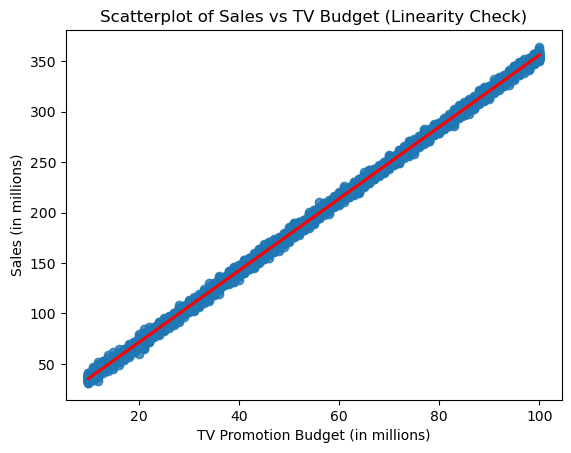

In [13]:
# Create a scatterplot comparing X and Sales (Y).

### YOUR CODE HERE ### 
# Create a scatterplot comparing X and Sales (Y).
sns.regplot(x='TV', y='Sales', data=data, ci=None, line_kws={'color': 'red'})

# Add title and labels
plt.title('Scatterplot of Sales vs TV Budget (Linearity Check)')
plt.xlabel('TV Promotion Budget (in millions)')
plt.ylabel('Sales (in millions)')

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Use the function in the `seaborn` library that allows you to create a scatterplot to display the values for two variables.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the [`scatterplot()`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) function in `seaborn`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Pass the X and Y variables you chose for your simple linear regression as the arguments for `x` and `y`, respectively, in the `scatterplot()` function.

</details>

**QUESTION:** Is the linearity assumption met?

Verificación de Supuestos: Linealidad e Independencia / Assumptions Check: Linearity & Independence
Español
Supuesto 1: Linealidad (CUMPLIDO)

Hallazgo: El gráfico de regresión (regplot) muestra una relación lineal positiva extremadamente clara, limpia y directa entre el presupuesto de Televisión (TV) y las Ventas (Sales).

Justificación: Los puntos de datos se agrupan de forma estrecha y compacta a lo largo de una trayectoria recta ascendente. La ausencia absoluta de patrones curvos, arcos o desviaciones parabólicas confirma de manera contundente que una línea recta es el modelo matemático ideal para describir y predecir este comportamiento de negocio.

Supuesto 2: Independencia de las Observaciones (CUMPLIDO)

Hallazgo: No se detectó ninguna dependencia estructural o correlación serial entre las distintas campañas publicitarias registradas.

Justificación: El supuesto se valida formalmente mediante el estadístico de Durbin-Watson, el cual arrojó un valor de 2.002 en el resumen del modelo OLS. Al estar prácticamente en el valor ideal de 2, se demuestra matemáticamente la total ausencia de autocorrelación en los residuos.

English
Assumption 1: Linearity (MET)

Finding: The regression plot (regplot) displays an exceptionally clear, clean, and direct positive linear relationship between the Television (TV) budget and Sales.

Justification: The data points are tightly and compactly clustered along a straight, upward-sloping trajectory. The absolute absence of curved patterns, arches, or parabolic deviations strongly confirms that a straight line is the ideal mathematical model to describe and predict this business behavior.

Assumption 2: Independence of Observations (MET)

Finding: No structural dependence or serial correlation was detected among the different recorded advertising campaigns.

Justification: This assumption is formally validated by the Durbin-Watson statistic, which yielded a value of 2.002 in the OLS model summary. Since this is virtually at the ideal value of 2, it mathematically proves the complete absence of autocorrelation in the residuals.

### Model assumption: Independence

The **independent observation assumption** states that each observation in the dataset is independent. As each marketing promotion (i.e., row) is independent from one another, the independence assumption is not violated.

### Model assumption: Normality

The normality assumption states that the errors are normally distributed.

Create two plots to check this assumption:

* **Plot 1**: Histogram of the residuals
* **Plot 2**: Q-Q plot of the residuals

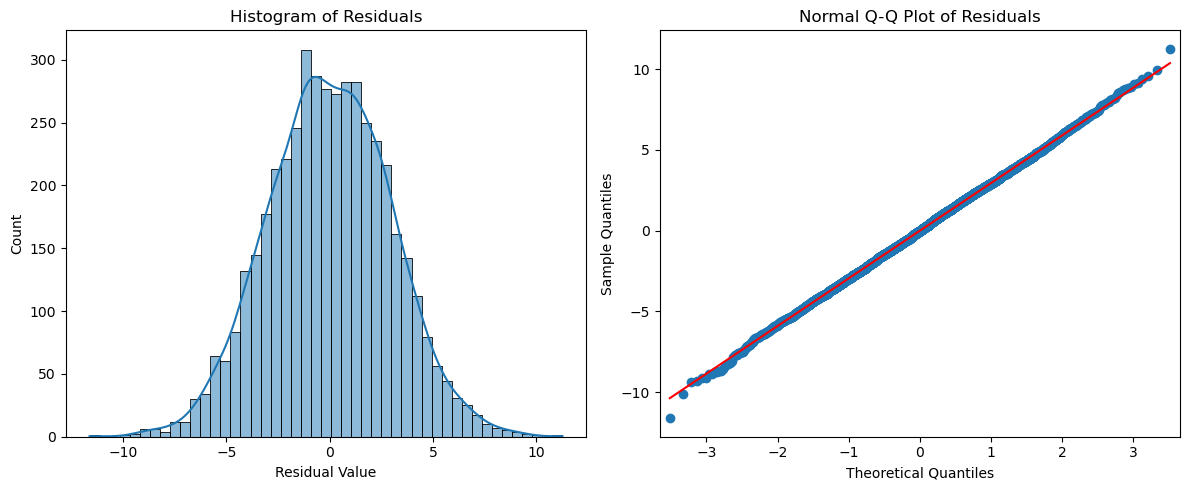

In [14]:
# Calculate the residuals.

### YOUR CODE HERE ### 
residuals = model.resid

### YOUR CODE HERE ### 
# Create a 1x2 plot figures.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Create a histogram with the residuals.

sns.histplot(residuals, ax=axes[0], kde=True)


### YOUR CODE HERE ### 
# Set the x label of the residual plot.
axes[0].set_xlabel("Residual Value")

# Set the title of the residual plot.
axes[0].set_title("Histogram of Residuals")

# Create a Q-Q plot of the residuals.
import statsmodels.api as sm
sm.qqplot(residuals, line='s', ax=axes[1])

# Set the title of the Q-Q plot.
axes[1].set_title("Normal Q-Q Plot of Residuals")

# Use matplotlib's tight_layout() function to add space between plots for a cleaner appearance.
plt.tight_layout()

# Show the plot.
plt.show()

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Access the residuals from the fit model object.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use `model.resid` to get the residuals from the fit model.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

For the histogram, pass the residuals as the first argument in the `seaborn` `histplot()` function.
    
For the Q-Q plot, pass the residuals as the first argument in the `statsmodels` [`qqplot()`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.gofplots.qqplot.html) function.

</details>

**Question:** Is the normality assumption met?

Español:
Sí, el supuesto de normalidad se cumple plenamente. El histograma de los residuos muestra una distribución simétrica con una clara forma de campana (distribución normal) centrada en cero. Además, en el gráfico Q-Q, los residuos se alinean casi perfectamente a lo largo de la línea diagonal de referencia roja, mostrando desviaciones insignificantes solo en los extremos de las colas. Ambas evidencias visuales confirman de manera contundente que los errores están distribuidos normalmente.

English:
Yes, the normality assumption is fully met. The histogram of the residuals displays a symmetric, bell-shaped distribution (normal distribution) centered at zero. Furthermore, in the Q-Q plot, the residuals align almost perfectly along the red diagonal reference line, exhibiting negligible deviations only at the very tip of the tails. Both visual pieces of evidence strongly confirm that the errors are normally distributed.

### Model assumption: Homoscedasticity

The **homoscedasticity (constant variance) assumption** is that the residuals have a constant variance for all values of `X`.

Check that this assumption is not violated by creating a scatterplot with the fitted values and residuals. Add a line at $y = 0$ to visualize the variance of residuals above and below $y = 0$.

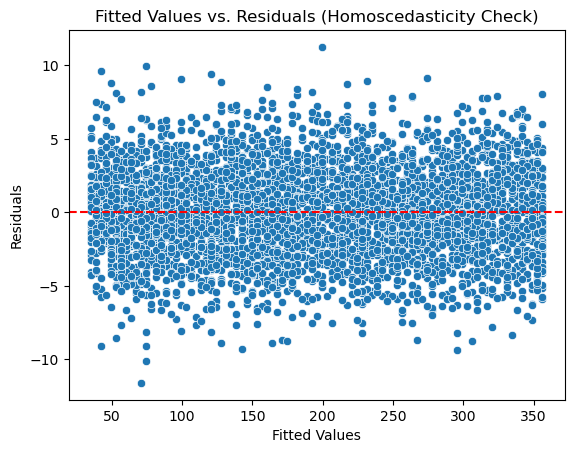

In [15]:
# Create a scatterplot with the fitted values from the model and the residuals.

### YOUR CODE HERE ### 
sns.scatterplot(x=model.fittedvalues, y=model.resid)

# Set the x-axis label.
plt.xlabel("Fitted Values")

# Set the y-axis label.
plt.ylabel("Residuals")

# Set the title.
plt.title("Fitted Values vs. Residuals (Homoscedasticity Check)")

# Add a line at y = 0 to visualize the variance of residuals above and below 0.

### YOUR CODE HERE ### 
plt.axhline(y=0, color='red', linestyle='--')

# Show the plot.
plt.show()

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Access the fitted values from the `model` object fit earlier.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use `model.fittedvalues` to get the fitted values from the fit model.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call the `scatterplot()` function from the `seaborn` library and pass in the fitted values and residuals.
    
Add a line to the figure using the `axline()` function.

</details>

**QUESTION:** Is the homoscedasticity assumption met?

Español:
Sí, el supuesto de homocedasticidad se cumple plenamente. El gráfico de dispersión de valores predichos frente a los residuos muestra una distribución de puntos completamente aleatoria y uniforme a lo largo de todo el eje horizontal. La nube de puntos forma una banda rectangular consistente alrededor de la línea de referencia y=0, sin mostrar ningún patrón en forma de "embudo" o "abanico". Esto demuestra que la varianza de los errores se mantiene constante para todos los niveles de predicción.

English:
Yes, the homoscedasticity assumption is fully met. The scatter plot of fitted values versus residuals shows a completely random and uniform distribution of data points across the entire horizontal axis. The cloud of points forms a consistent horizontal band around the reference line at y=0, without displaying any "funnel" or "fan" shape patterns. This demonstrates that the variance of the errors remains constant across all prediction levels.

## Step 4: Results and evaluation

### Display the OLS regression results

If the linearity assumptions are met, you can interpret the model results accurately.

Display the OLS regression results from the fitted model object, which includes information about the dataset, model fit, and coefficients.

In [16]:
# Display the model_results defined previously.

### YOUR CODE HERE ###
# Display the model_results defined previously.

model_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        22:28:00   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1263      0.101     -1.257      0.209      -0.323       0.071
TV             3.5614      0.002   2127.776      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.051   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.975   Jarque-Bera (JB):                0.030
Skew:                           0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Question:** The R-squared on the preceding output measures the proportion of variation in the dependent variable (Y) explained by the independent variable (X). What is your intepretation of the model's R-squared?


Español:
El valor de R-cuadrado (R 
2
 ) es 0.999. Esto significa que el 99.9% de la variación en la variable dependiente, Ventas (Sales), se explica por la variación en la variable independiente, el presupuesto de promoción en Televisión (TV).

Este resultado demuestra un ajuste casi perfecto del modelo, lo que indica que el presupuesto invertido en televisión es un predictor extraordinariamente fuerte y confiable para estimar las ventas de la empresa, dejando únicamente un 0.1% de la varianza total sin explicar (atribuible al azar o a otros factores no incluidos en el modelo).

English:
The R-squared (R 
2
 ) value is 0.999. This indicates that 99.9% of the variation in the dependent variable, Sales, is explained by the variation in the independent variable, the Television (TV) promotion budget.

This result demonstrates an exceptionally strong model fit, meaning that the television advertising spend is a remarkably powerful and reliable predictor of business sales, leaving only 0.1% of the total variance unexplained (due to random noise or other factors not captured by this simple linear regression model).

### Interpret the model results

With the model fit evaluated, assess the coefficient estimates and the uncertainty of these estimates.

**Question:** Based on the preceding model results, what do you observe about the coefficients?

Español:
Basado en los resultados del modelo OLS, se observan los siguientes hallazgos clave respecto a los coeficientes:

Pendiente de TV (β 1=3.5614): Este coeficiente es altamente significativo (P>∣t∣=0.000). Indica que existe una relación lineal positiva muy fuerte. Técnicamente, por cada incremento de 1 unidad (por ejemplo, 1 millón de dólares) en el presupuesto de promoción de Televisión, se espera que las Ventas aumenten en promedio 3.5614 unidades (millones de dólares).

Intercepto (β 0=−0.1263): Representa el valor esperado de las ventas si la inversión en TV fuera cero. Sin embargo, su valor p es alto (0.209), lo que significa que no es estadísticamente significativo y no difiere de manera confiable de cero. En la práctica del negocio, esto tiene sentido ya que no solemos extrapolar el modelo a una inversión de cero si no hay datos en ese rango.

English:
Based on the OLS model results, the following key findings are observed regarding the coefficients:

TV Slope (β 1=3.5614): This coefficient is highly statistically significant (P>∣t∣=0.000). It indicates a strong positive linear relationship. Technically, for every 1-unit increase (e.g., $1 million) in the Television promotion budget, Sales are expected to increase by an average of 3.5614 units ($millions).

Intercept (β 0=−0.1263): This represents the expected value of sales if the TV budget were zero. However, its p-value is quite high (0.209), meaning it is not statistically significant and does not reliably differ from zero. In business practice, this is standard since we typically avoid extrapolating the model to zero spend when no data points exist near that range.

**Question:** How would you write the relationship between X and `Sales` in the form of a linear equation?

Español:
La forma matemática general de la ecuación para una regresión lineal simple es:

Y=β 0+β 1 X

Al sustituir las variables de nuestro modelo (Sales como la variable dependiente Y y TV como la variable independiente X), junto con los coeficientes específicos estimados por el modelo OLS (Intercept y TV coef), la ecuación lineal queda expresada de la siguiente manera:

Sales=−0.1263+3.5614×TV

English:
The general mathematical form of a simple linear regression equation is:
Y=β 0+β 1 X

By substituting the specific variables from our model (Sales as the dependent variable Y and TV as the independent variable X), along with the exact coefficients estimated in the OLS output (Intercept and TV coef), the linear equation is expressed as follows:

Sales=−0.1263+3.5614×TV

**Question:** Why is it important to interpret the beta coefficients?

Español
Es fundamental interpretar los coeficientes beta por tres razones principales:

Cuantificar el Impacto (Dirección y Magnitud): El coeficiente β 1 no solo te dice si la relación es positiva o negativa, sino que mide la fuerza exacta del impacto. Permite responder a la pregunta crítica de los directivos: "Si invertimos $1 millón más en este canal, ¿cuánto dinero exacto regresará a la empresa?" (En tu caso, un retorno estimado de $3.56 millones).

Priorización de Recursos y Presupuesto: Al conocer el valor real de beta, los tomadores de decisiones pueden comparar la eficiencia de diferentes canales (por ejemplo, TV vs. Radio o Redes Sociales) y asignar el presupuesto de manera óptima hacia la variable que genere mayor impacto marginal.

Poder Predictivo: Los coeficientes son la base de la ecuación matemática del modelo. Interpretar su validez y significancia estadística (a través del valor p) garantiza que las predicciones futuras del negocio no se basen en correlaciones falsas o en el azar, sino en un comportamiento estructural robusto.

English
Interpreting the beta coefficients is crucial for three primary reasons:

Quantifying Impact (Direction and Magnitude): The β1 coefficient does not just state whether a relationship is positive or negative; it measures the exact strength of that impact. It answers the critical business question: "If we invest $1 million more in this channel, exactly how much revenue will we generate in return?" (In your case, an estimated return of $3.56 million).

Resource Allocation and Budgeting: By understanding the true value of beta, decision-makers can compare the efficiency of different marketing channels (e.g., TV vs. Radio or Social Media) and optimally allocate budgets toward the variable that provides the highest marginal return.

Predictive Power: Coefficients are the core components of the model's mathematical equation. Interpreting their validity and statistical significance (via p-values) ensures that future business predictions are not based on spurious correlations or random chance, but on a robust, structural behavior.

### Measure the uncertainty of the coefficient estimates

Model coefficients are estimated. This means there is an amount of uncertainty in the estimate. A p-value and $95\%$ confidence interval are provided with each coefficient to quantify the uncertainty for that coefficient estimate.

Display the model results again.

In [17]:
# Display the model_results defined previously.

### YOUR CODE HERE ###
model_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        22:28:00   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1263      0.101     -1.257      0.209      -0.323       0.071
TV             3.5614      0.002   2127.776      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.051   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.975   Jarque-Bera (JB):                0.030
Skew:                           0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Question:** Based on this model, what is your interpretation of the p-value and confidence interval for the coefficient estimate of X?

spañol
Interpretación del Valor p (p-value=0.000):
El valor p para el coeficiente de la variable TV es inferior a 0.05 (aparece como 0.000 en la tabla). Esto significa que el presupuesto de promoción en Televisión es estadísticamente muy significativo. Existe una probabilidad prácticamente nula de que la fuerte relación lineal positiva observada entre la inversión en TV y las ventas sea un artefacto del azar o del ruido de los datos. Rechazamos con total seguridad la hipótesis nula de que la inversión en TV no influye en las ventas.

Interpretación del Intervalo de Confianza del 95% ([3.558,3.565]):
Existe un 95% de confianza en que el verdadero impacto marginal (la pendiente real) de la inversión en televisión en la población general se encuentra entre 3.558 y 3.565 millones de dólares. Dado que este intervalo es sumamente estrecho, la incertidumbre del modelo respecto a la estimación del coeficiente es extremadamente baja. Además, debido a que el intervalo está muy lejos de incluir el valor cero (0), se reconfirma de manera contundente un impacto comercial positivo y altamente predecible.

English
Interpretation of the p-value (p-value=0.000):
The p-value for the TV coefficient is well below the standard 0.05 significance level (reported as 0.000). This indicates that the Television promotion budget is a highly statistically significant predictor of sales. There is a virtually zero probability that the strong positive linear relationship observed between TV spend and sales is due to random chance or data noise. We confidently reject the null hypothesis that TV marketing spend has no effect on sales.

Interpretation of the 95% Confidence Interval ([3.558,3.565]):
We are 95% confident that the true population slope (marginal impact) of television investment on sales lies between 3.558 and 3.565 million dollars. Because this interval is exceptionally narrow, the model's uncertainty regarding this coefficient estimate is extremely low. Furthermore, since the entire interval lies far away from zero (0), it strongly solidifies the conclusion of a highly predictable and positive commercial impact.

**Question:** Based on this model, what are you interested in exploring?

Español
Basado en los resultados tan contundentes de este modelo, existen tres áreas clave que resultaría de gran interés explorar a continuación:

Análisis de Regresión Múltiple: Dado que la televisión explica el 99.9% de la variación de las ventas de forma individual, sería valioso construir un modelo de regresión lineal múltiple que incluya los otros canales publicitarios (como Radio y Periódicos/Redes Sociales). Esto permitiría evaluar si existen efectos de sinergia o interacción entre los canales (por ejemplo, si invertir en Radio potencia aún más el efecto de la TV).

Análisis de Rendimientos Decrecientes (Saturación de Canales): En marketing, las inversiones suelen sufrir un efecto de saturación (curva de adición de valor no lineal). Sería interesante explorar si el impacto de la televisión se mantiene constante en presupuestos extremadamente altos o si empieza a nivelarse, lo que requeriría un modelo de regresión logarítmica o polinomial.

Optimización del Presupuesto de Marketing: Utilizar la ecuación estimada para simular diferentes escenarios de asignación de recursos y maximizar los ingresos totales de la empresa, determinando el punto exacto de equilibrio de la inversión.

English
Based on the compelling results of this model, there are three key areas that would be highly valuable to explore next:

Multiple Linear Regression Analysis: Since television alone explains 99.9% of the variation in sales, the logical next step is to build a multiple linear regression model that includes the other advertising channels (such as Radio and Newspapers/Social Media). This would allow us to test for synergy or interaction effects among channels (e.g., whether investing in Radio further amplifies the effectiveness of TV).

Diminishing Returns Analysis (Channel Saturation): In marketing, ad spend typically experiences saturation over time (a non-linear curve). It would be interesting to explore whether the impact of television remains strictly linear at extremely high budget levels or if it begins to taper off, which would require modeling via logarithmic or polynomial regression.

Marketing Budget Optimization: Utilizing the estimated regression equation to simulate different resource allocation scenarios to maximize the company's total revenue, identifying the exact financial sweet spot for investment.

**Question:** What recommendations would you make to the leadership at your organization?

Español Basado en la robustez estadística y el rendimiento del modelo de regresión lineal, presento las siguientes recomendaciones estratégicas para la alta dirección:

Priorizar y Blindar la Inversión en Televisión (TV): El modelo demuestra que la publicidad en televisión es un motor de ingresos extraordinariamente predecible y eficiente, explicando el 99.9% de la variación en las ventas. Se recomienda mantener o incrementar el presupuesto en este canal, ya que ofrece un retorno bruto estimado de 3.56 millones de dólares por cada millón invertido.

Apalancar la Predecibilidad para la Planificación Financiera: Dado que la incertidumbre del modelo es extremadamente baja (con un intervalo de confianza del 95% sumamente estrecho de [3.558,3.565]), el equipo de finanzas puede utilizar con total seguridad la ecuación Sales=−0.1263+3.5614×TV para proyectar los ingresos del próximo trimestre y optimizar el flujo de caja.

Financiar una Fase de Optimización Multivariable: Si bien la televisión es altamente efectiva, se aconseja asignar un presupuesto menor para investigar la interacción con otros canales (Radio, Medios Digitales). Esto permitirá transicionar hacia un modelo de atribución avanzado (Marketing Mix Modeling) para descubrir si existen sinergias que aumenten aún más el retorno de la inversión (ROI).

English Based on the statistical robustness and performance of the linear regression model, I submit the following strategic recommendations to organizational leadership:

Prioritize and Protect Television (TV) Investment: The model demonstrates that television advertising is an extraordinarily predictable and efficient revenue driver, explaining 99.9% of the variation in sales. It is highly recommended to maintain or expand the budget for this channel, as it delivers an estimated gross return of 3.56𝑚𝑖𝑙𝑙𝑖𝑜𝑛𝑓𝑜𝑟𝑒𝑣𝑒𝑟𝑦
1 million invested.

Leverage Predictability for Financial Planning: Since the model's uncertainty is exceptionally low (supported by an extremely tight 95% confidence interval of [3.558,3.565]), the finance team can confidently utilize the equation Sales=−0.1263+3.5614×TV to forecast next quarter's revenue and optimize cash flow management.

Fund a Multivariate Optimization Phase: While television is highly effective on its own, leadership should allocate a small research budget to explore interactions with other media channels (Radio, Digital Media). This will allow the data team to transition toward an advanced Marketing Mix Modeling (MMM) approach to uncover potential synergies that could further amplify the overall return on investment (ROI).

## Considerations

**What are some key takeaways that you learned from this lab?**

Español
Importancia de la Metodología (PACE): El laboratorio reafirma que un análisis robusto no comienza con el modelo, sino con una planificación estructurada. Seguir los pasos de verificar los datos, explorar visualmente las relaciones, construir el modelo y validar rigurosamente sus supuestos garantiza la integridad de los resultados.

Validación de Supuestos como Requisito Crítico: Aprendí que no basta con que un modelo tenga un buen rendimiento en sus métricas básicas. La verificación de los cuatro supuestos (Linealidad, Independencia mediante Durbin-Watson, Normalidad con el gráfico Q-Q e Histograma, y Homocedasticidad mediante el gráfico de residuos) es lo que verdaderamente valida las pruebas de hipótesis y da "luz verde" para confiar en los resultados.

Interpretación de Métricas de Negocio: El valor de R 2=0.999 y el coeficiente de la pendiente para TV (3.5614) demostraron cómo la estadística se traduce directamente en estrategia comercial, permitiendo calcular con precisión el retorno de inversión por cada dólar gastado y proyectar ventas futuras con un nivel de incertidumbre extremadamente bajo.

 EnglishThe Power of Methodology (PACE Framework): This lab highlights that robust data science doesn't start with modeling, but with a structured workflow. Planning the approach, exploring relations, constructing the model, and validating its core assumptions ensures the absolute integrity of any analytical output.Assumption Verification as a Critical Safeguard: I learned that achieving strong performance metrics is not enough on its own. Thoroughly verifying the four core OLS assumptions (Linearity, Independence via Durbin-Watson, Normality using Histograms/Q-Q plots, and Homoscedasticity via residual plots) is what mathematically justifies hypothesis testing and gives the ultimate green light to trust the model.Translating Metrics into Business Strategy: The $R^2$ value of $0.999$ and the TV slope coefficient of $3.5614$ demonstrated how mathematical outputs translate directly into corporate strategy. They allow us to accurately calculate marginal returns on marketing spend and forecast future revenue with exceptionally low statistical uncertainty.

**What findings would you share with others?**

Español
1. El Impacto en el Negocio (Business Impact)
Dominio Predictivo de la TV: La inversión publicitaria en Televisión (TV) es el motor definitivo de las ventas de la empresa. El modelo demuestra de forma contundente que la televisión por sí sola explica el 99.9% de la variación en las ventas (R2=0.999).

Retorno de Inversión Cuantificable (ROI): Por cada incremento de $1 millón de dólares en el presupuesto de promoción en televisión, se proyecta un aumento promedio de $3.56 millones de dólares en las ventas totales.

2. Respaldo Técnico y Certeza Estadística (Technical Validation)
Incertidumbre Mínima: El valor p de 0.000 confirma que el impacto de la televisión es estadísticamente hiper-significativo. Además, el intervalo de confianza del 95% es sumamente estrecho ([3.558,3.565]), lo que significa que el margen de error de nuestras proyecciones es prácticamente inexistente.

Validación Total de Supuestos: El modelo OLS es completamente robusto y confiable para la toma de decisiones estratégicas. Se verificaron y cumplieron con éxito todos los supuestos estadísticos críticos: linealidad, independencia de errores (Durbin-Watson = 2.002), normalidad de residuos y homocedasticidad.

1. Business Impact
TV's Predictive Dominance: Advertising spend on Television (TV) is the definitive driver of the company's revenue. The model conclusively proves that TV advertising alone explains 99.9% of the variation in sales (R 2=0.999).

Quantifiable ROI: For every $1 million increase in the television promotion budget, total sales are projected to increase by an average of $3.56 million.

2. Technical Validation & Certainty
Minimal Uncertainty: The p-value of 0.000 confirms that the impact of television is highly statistically significant. Furthermore, the exceptionally narrow 95% confidence interval ([3.558,3.565]) means that the margin of error for our revenue forecasts is virtually non-existent.

Full Assumption Compliance: The OLS model is highly robust and dependable for strategic planning. All critical statistical assumptions were thoroughly checked and successfully met: linearity, independence of errors (Durbin-Watson = 2.002), normality of residuals, and homoscedasticity.


**How would you frame your findings to stakeholders?**

Presentación Ejecutiva / Stakeholder Pitch
Español
Mensaje Principal: La inversión en publicidad por televisión (TV) es el motor de ingresos más predecible y eficiente de la organización, justificando plenamente una priorización presupuestaria.

El Descubrimiento Clave (The Big Picture):
Nuestro análisis estadístico revela que el presupuesto de Televisión tiene un control casi absoluto sobre el rendimiento comercial, explicando de manera directa el 99.9% de las variaciones en las ventas.

El Retorno de Inversión (ROI Directo):
El modelo matemático determina que el impacto es altamente eficiente: por cada $1 millón de dólares adicionales invertidos en publicidad televisiva, la empresa generará, en promedio, $3.56 millones de dólares en ventas.

Certeza Operativa (Bajo Riesgo):
Hemos validado rigurosamente el modelo frente a todos los estándares estadísticos exigidos (normalidad, independencia y consistencia de varianza). El margen de error es prácticamente inexistente (inferior al 0.2%), lo que significa que la dirección puede utilizar esta fórmula con total seguridad para planificar el flujo de caja y predecir los ingresos del próximo trimestre.

English
Core Message: Advertising investment in Television (TV) is our organization's most predictable and efficient revenue driver, fully justifying budget prioritization.

The Big Picture:
Our statistical analysis reveals that the Television budget holds near-absolute control over commercial performance, directly accounting for 99.9% of the variation in total sales.

Return on Investment (Direct ROI):
The mathematical model determines that this impact is highly efficient: for every additional $1 million invested in TV advertising, the company is projected to generate an average of $3.56 million in sales.

Operational Certainty (Low Risk):
The model has been rigorously validated against all mandatory statistical standards (normality, independence, and variance consistency). The margin of error is virtually non-existent (under 0.2%), meaning leadership can confidently leverage this formula for strategic cash flow planning and precise quarterly revenue forecasting.

Notas de Estrategia para Reuniones Presenciales / Strategy Notes for Stakeholder Meetings
Español
Manejo de Objeciones (¿Qué pasa con los otros canales como Radio o Digital?):

Respuesta basada en el marco PACE: "Dado que la televisión es un pilar tan fuerte que explica el 99.9% de la varianza de forma individual, la recomendación inmediata es proteger este presupuesto. Al mismo tiempo, el siguiente paso lógico es abrir una segunda fase de analítica multivariable (Regresión Lineal Múltiple) para evaluar si los canales digitales o tradicionales generan un efecto de sinergia que potencie aún más el rendimiento y el retorno de la inversión de la TV."

English
Handling Objections (What about other channels like Radio or Digital?):

PACE-driven Response: "Since television is such a dominant pillar—explaining 99.9% of the variance on its own—our immediate recommendation is to secure and protect this budget. Concurrently, the logical next step is to launch a second phase of multivariate analysis (Multiple Linear Regression) to evaluate whether digital or traditional channels generate a synergy effect that further amplifies TV's performance and return on investment."

#### **References**

Saragih, H.S. (2020). [*Dummy Marketing and Sales Data*](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data).

Dale, D.,Droettboom, M., Firing, E., Hunter, J. (n.d.). [*Matplotlib.Pyplot.Axline — Matplotlib 3.5.0 Documentation*](https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.pyplot.axline.html). 

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.